In [64]:
# PCA interpretation notebook: timewise discriminant score and separation metrics
# Author: autogenerated by assistant

from __future__ import annotations

import os
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# -------------------------------
# Configuration
# -------------------------------
PROJECT_ROOT = Path("/Users/johnmadrid/GitHub/pca-driving-behavior").resolve()
DATA_CSV = PROJECT_ROOT / "results/cleaned_new/event_one/cleaned_event_one_timestamp_all_7_variables.csv"
OUTPUT_DIR = PROJECT_ROOT / "results/pc-interp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Variables to use (column names in the cleaned CSV)
FEATURES = [
    "Eye Horizontal",
    "Eye Vertical",
    "Car Yaw",
    "Head Yaw",
    "Head Pitch",
    "Head Roll",
    "Steering",
]

TIME_COL = "Time"
COND_COL = "Condition"  # 0/1 numeric codes in the cleaned CSV
EVENT_COL = "Event"

# Optional: mark hazard onset (seconds); set to None if unknown
HAZARD_ONSET: float | None = None  # e.g., 22.5

# Bootstrap and CV settings
BOOTSTRAP_REPS = 200
CV_FOLDS = 5
RANDOM_STATE = 42

# Permutation test settings
PERM_REPS = 200  # increase (e.g., 1000) for publication; 200 for speed
FDR_ALPHA = 0.05

# Practical AUC threshold for strong separation
PRACTICAL_AUC_THRESH = 0.80

np.random.seed(RANDOM_STATE)

# Plot style
mpl.rcParams.update({
    "figure.figsize": (11, 6.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
})

print(f"Reading: {DATA_CSV}")
df = pd.read_csv(DATA_CSV)
# Keep only needed columns to reduce memory
required_cols = FEATURES + [COND_COL, TIME_COL, EVENT_COL]
df = df[required_cols].copy()

# Map numeric condition to labels for plotting
COND_MAP = {0: "Manual", 1: "Autonomous"}
df["ConditionName"] = df[COND_COL].map(COND_MAP)

# Sort by time for stable iteration
unique_times = np.sort(df[TIME_COL].unique())
print(f"Found {len(unique_times)} unique timestamps; rows: {len(df):,}")



Reading: /Users/johnmadrid/GitHub/pca-driving-behavior/results/cleaned_new/event_one/cleaned_event_one_timestamp_all_7_variables.csv
Found 508 unique timestamps; rows: 144,272


In [65]:
# Debug/verbosity controls
DEBUG = True  # set False to silence prints
# Choose which times to print detailed diagnostics for. By default: first timestamp only.
DEBUG_TIMES = []  # e.g., [20.84, 23.78]
MAX_DEBUG_PRINTS = 2

In [66]:
# Helper functions

def _compute_pca_scores(X: np.ndarray, n_components: int = 2) -> Tuple[np.ndarray, PCA, StandardScaler]:
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=n_components, svd_solver="full", random_state=RANDOM_STATE)
    scores = pca.fit_transform(Xs)
    return scores, pca, scaler


def _compute_discriminant(scores: np.ndarray, y: np.ndarray, prev_v: np.ndarray | None) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float, float, float]:
    # centroids in score space
    c0 = scores[y == 0].mean(axis=0)
    c1 = scores[y == 1].mean(axis=0)
    v = c0 - c1
    norm = np.linalg.norm(v)
    if norm == 0 or np.isnan(norm):
        v = np.array([1.0, 0.0])
        norm = 1.0
    else:
        v = v / norm

    # Ensure temporal orientation continuity
    if prev_v is not None and np.dot(v, prev_v) < 0:
        v = -v

    m = 0.5 * (c0 + c1)
    # project to scalar
    s = (scores - m) @ v
    s0 = np.nanmean(s[y == 0])
    s1 = np.nanmean(s[y == 1])
    dist = float(np.linalg.norm(c0 - c1))
    return v, m, s, float(s0), float(s1), dist


def _cv_auc(scores: np.ndarray, y: np.ndarray, n_splits: int = CV_FOLDS) -> float:
    # Robust choice of folds
    class_counts = np.bincount(y)
    max_folds = int(np.clip(class_counts.min(), 2, n_splits))
    if max_folds < 2:
        # Fallback: in-sample AUC (optimistic)
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores, y)
        prob = clf.predict_proba(scores)[:, 1]
        return float(roc_auc_score(y, prob))
    skf = StratifiedKFold(n_splits=max_folds, shuffle=True, random_state=RANDOM_STATE)
    prob_all = np.zeros(len(y))
    for train, test in skf.split(scores, y):
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores[train], y[train])
        prob_all[test] = clf.predict_proba(scores[test])[:, 1]
    return float(roc_auc_score(y, prob_all))


def _oof_probabilities(scores: np.ndarray, y: np.ndarray, n_splits: int = CV_FOLDS) -> np.ndarray:
    """Return out-of-fold probabilities for class 1. Falls back to in-sample if folds<2."""
    class_counts = np.bincount(y)
    max_folds = int(np.clip(class_counts.min(), 2, n_splits))
    if max_folds < 2:
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores, y)
        return clf.predict_proba(scores)[:, 1]
    skf = StratifiedKFold(n_splits=max_folds, shuffle=True, random_state=RANDOM_STATE)
    prob_all = np.zeros(len(y))
    for train, test in skf.split(scores, y):
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores[train], y[train])
        prob_all[test] = clf.predict_proba(scores[test])[:, 1]
    return prob_all


def _bootstrap_ci_scores(scores: np.ndarray, y: np.ndarray, reps: int = BOOTSTRAP_REPS,
                          random_state: int = RANDOM_STATE,
                          prev_v: np.ndarray | None = None) -> Dict[str, Tuple[float, float]]:
    rng = np.random.default_rng(random_state)
    s0_vals, s1_vals, dist_vals = [], [], []
    v = prev_v
    for _ in range(reps):
        # resample within each class
        idx0 = np.where(y == 0)[0]
        idx1 = np.where(y == 1)[0]
        if len(idx0) == 0 or len(idx1) == 0:
            break
        b0 = rng.choice(idx0, size=len(idx0), replace=True)
        b1 = rng.choice(idx1, size=len(idx1), replace=True)
        bidx = np.concatenate([b0, b1])
        b_scores = scores[bidx]
        b_y = y[bidx]
        v, m, s, s0, s1, dist = _compute_discriminant(b_scores, b_y, v)
        s0_vals.append(s0)
        s1_vals.append(s1)
        dist_vals.append(dist)
    def ci(x):
        if len(x) == 0:
            return (np.nan, np.nan)
        lo, hi = np.percentile(x, [2.5, 97.5])
        return (float(lo), float(hi))
    return {
        "s0": ci(s0_vals),
        "s1": ci(s1_vals),
        "dist": ci(dist_vals),
    }


def _perm_p_values(scores: np.ndarray, y: np.ndarray, perm_reps: int = PERM_REPS) -> Tuple[float, float]:
    """
    Return (p_auc, p_dist) by permuting labels and recomputing AUC and centroid distance.
    Uses the same scores (aligned PC plane). AUC uses in-sample logistic if folds<2.
    """
    # Observed
    auc_obs = _cv_auc(scores, y, CV_FOLDS)
    _, _, _, _, _, dist_obs = _compute_discriminant(scores, y, prev_v=None)

    rng = np.random.default_rng(RANDOM_STATE)
    auc_perm = []
    dist_perm = []
    for _ in range(perm_reps):
        y_perm = rng.permutation(y)
        auc_p = _cv_auc(scores, y_perm, CV_FOLDS)
        _, _, _, _, _, dist_p = _compute_discriminant(scores, y_perm, prev_v=None)
        auc_perm.append(auc_p)
        dist_perm.append(dist_p)

    auc_perm = np.asarray(auc_perm)
    dist_perm = np.asarray(dist_perm)
    p_auc = float((1 + np.sum(auc_perm >= auc_obs)) / (1 + perm_reps))
    p_dist = float((1 + np.sum(dist_perm >= dist_obs)) / (1 + perm_reps))
    return p_auc, p_dist


def _pr_from_probs(y: np.ndarray, prob: np.ndarray) -> Dict[str, float]:
    """Compute per-time PR metrics from OOF probabilities."""
    from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
    precision, recall, thresholds = precision_recall_curve(y, prob)
    ap = float(average_precision_score(y, prob))
    # Fixed threshold @ 0.5
    yhat_05 = (prob >= 0.5).astype(int)
    from sklearn.metrics import precision_score, recall_score
    p05 = float(precision_score(y, yhat_05, zero_division=0))
    r05 = float(recall_score(y, yhat_05, zero_division=0))
    try:
        f105 = float(f1_score(y, yhat_05))
    except Exception:
        f105 = float(0.0)
    # Max F1 over thresholds
    f1s = 2 * (precision * recall) / np.maximum(precision + recall, 1e-12)
    idx = int(np.nanargmax(f1s))
    f1max = float(f1s[idx])
    # thresholds array has length-1 of precision/recall; clamp index
    if idx >= len(thresholds):
        idx_thr = len(thresholds) - 1
    else:
        idx_thr = idx
    thr_star = float(thresholds[max(0, idx_thr)]) if thresholds.size > 0 else float(0.5)
    p_star = float(precision[min(idx, len(precision) - 1)])
    r_star = float(recall[min(idx, len(recall) - 1)])
    prevalence = float(np.mean(y))
    # TPR@0.5 and FPR@0.5
    tp = float(np.sum((y == 1) & (yhat_05 == 1)))
    fn = float(np.sum((y == 1) & (yhat_05 == 0)))
    tn = float(np.sum((y == 0) & (yhat_05 == 0)))
    fp = float(np.sum((y == 0) & (yhat_05 == 1)))
    tpr05 = tp / max(tp + fn, 1.0)
    fpr05 = fp / max(fp + tn, 1.0)
    youden = tpr05 - fpr05
    return {
        "AP": ap,
        "precision_0p5": p05,
        "recall_0p5": r05,
        "f1_0p5": f105,
        "f1_max": f1max,
        "thresh_f1_max": thr_star,
        "precision_f1_max": p_star,
        "recall_f1_max": r_star,
        "prevalence": prevalence,
        "tpr_0p5": tpr05,
        "fpr_0p5": fpr05,
        "youden_j": youden,
    }



In [67]:
# Alignment helpers: sign flips + optional orthogonal Procrustes

import numpy.linalg as npl


def _orthogonal_procrustes(A: np.ndarray, B: np.ndarray, allow_reflection: bool = False) -> np.ndarray:
    """
    Return R (2x2) minimizing ||A R - B||_F with R orthogonal.
    A and B are [n_features x 2] loading matrices.
    """
    S = A.T @ B  # 2x2
    U, _, Vt = npl.svd(S)
    R = U @ Vt
    if not allow_reflection and np.linalg.det(R) < 0:
        U[:, -1] *= -1.0
        R = U @ Vt
    return R


def _align_basis(loadings: np.ndarray, ref_loadings: np.ndarray | None,
                  prev_loadings: np.ndarray | None) -> Tuple[np.ndarray, np.ndarray]:
    """
    Align current [n_features x 2] loadings to reference basis.
    Returns (aligned_loadings, R). Applies Procrustes rotation; then enforces
    column-wise sign continuity vs prev_loadings if provided.
    """
    if ref_loadings is None:
        R = np.eye(2)
        aligned = loadings.copy()
    else:
        R = _orthogonal_procrustes(loadings, ref_loadings, allow_reflection=False)
        aligned = loadings @ R
    # Enforce continuity of each component sign using prev_loadings if available
    if prev_loadings is not None:
        for j in range(aligned.shape[1]):
            if np.dot(aligned[:, j], prev_loadings[:, j]) < 0:
                aligned[:, j] *= -1.0
                R[:, j] *= -1.0
    return aligned, R



In [81]:
# Model performance plot: AP and precision/recall/F1 over time

def plot_model_performance(metrics_df: pd.DataFrame, out_suffix: str = "aligned") -> None:
    times = metrics_df["Time"].to_numpy()
    fig, axes = plt.subplots(4, 1, figsize=(10,8), sharex=True)

    # Panel 1: Average Precision (AP) and prevalence reference
    ax = axes[0]
    ax.plot(times, metrics_df["AP"], color="#1b9e77", label="AP")
    ax.axhline(metrics_df["prevalence"].mean(), color="gray", ls=":", lw=1, alpha=0.7, label="Prevalence")
    ax.set_ylabel("Average Precision")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 2: Precision/Recall at threshold 0.5
    ax = axes[1]
    ax.plot(times, metrics_df["precision_0p5"], color="#7570b3", label="Precision@0.5")
    ax.plot(times, metrics_df["recall_0p5"], color="#d95f02", label="Recall@0.5")
    ax.set_ylabel("P/R @0.5")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 3: Max F1 and its threshold (as a secondary axis marker if desired)
    ax = axes[2]
    ax.plot(times, metrics_df["f1_max"], color="#e7298a", label="Max F1")
    ax.set_ylabel("Max F1")
    ax.set_xlim(times.min(), times.max())
    ax.set_ylim(0.0, 1.0)
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 4: TPR/FPR/Youden at threshold 0.5
    ax = axes[3]
    ax.plot(times, metrics_df["tpr_0p5"], color="#1f78b4", label="TPR@0.5")
    ax.plot(times, metrics_df["fpr_0p5"], color="#e31a1c", label="FPR@0.5")
    ax.plot(times, metrics_df["youden_j"], color="#33a02c", ls="--", label="Youden's J")
    ax.axhline(0.0, color="gray", ls=":", lw=1, alpha=0.7)
    ax.set_ylabel("TPR/FPR/Youden @0.5")
    ax.set_xlabel("Time (s)")
    ax.set_xlim(times.min(), times.max())
    ax.set_ylim(0.0, 1.0)
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    fig.tight_layout()
    out_path = OUTPUT_DIR / f"model_performance_{out_suffix}.png"
    fig.savefig(out_path, dpi=200)
    print("Saved:", out_path)


In [73]:
# Consolidated: compute metrics and plot panels (aligned or not)
from typing import Dict

def compute_timewise_pca_metrics(df_in: pd.DataFrame,
                                 feature_cols: List[str],
                                 align: bool = True,
                                 out_suffix: str = "aligned") -> pd.DataFrame:
    ref_loadings: np.ndarray | None = None
    prev_loadings: np.ndarray | None = None
    prev_v: np.ndarray | None = None
    records: List[Dict[str, float]] = []

    pvals_auc = []
    pvals_dist = []

    for t in np.sort(df_in[TIME_COL].unique()):
        dft = df_in[df_in[TIME_COL] == t]
        X = dft[feature_cols].to_numpy(dtype=float)
        y = dft[COND_COL].to_numpy(dtype=int)
        if X.shape[0] < 3:
            continue

        scores_raw, pca, scaler = _compute_pca_scores(X, n_components=2)
        if align:
            loadings = pca.components_.T
            aligned_loadings, R = _align_basis(loadings, ref_loadings, prev_loadings)
            scores = scores_raw @ R
            if ref_loadings is None:
                ref_loadings = aligned_loadings.copy()
            prev_loadings = aligned_loadings.copy()
        else:
            scores = scores_raw

        v, m, s, s0, s1, dist = _compute_discriminant(scores, y, prev_v)
        prev_v = v
        cis = _bootstrap_ci_scores(scores, y, BOOTSTRAP_REPS, RANDOM_STATE, prev_v)
        auc = _cv_auc(scores, y, CV_FOLDS)

        # Permutation p-values per time
        p_auc, p_dist = _perm_p_values(scores, y, PERM_REPS)
        pvals_auc.append(p_auc)
        pvals_dist.append(p_dist)

        # OOF probabilities and PR metrics
        prob_oof = _oof_probabilities(scores, y, CV_FOLDS)
        pr_metrics = _pr_from_probs(y, prob_oof)

        records.append({
            "Time": float(t),
            "Manual_score_mean": s0,
            "Autonomous_score_mean": s1,
            "Manual_score_lo": cis["s0"][0],
            "Manual_score_hi": cis["s0"][1],
            "Autonomous_score_lo": cis["s1"][0],
            "Autonomous_score_hi": cis["s1"][1],
            "CentroidDistance": dist,
            "CentroidDistance_lo": cis["dist"][0],
            "CentroidDistance_hi": cis["dist"][1],
            "AUC": auc,
            "p_auc": p_auc,
            "p_dist": p_dist,
            "auc_ge_thresh": bool(auc >= PRACTICAL_AUC_THRESH),
            # PR metrics
            "AP": pr_metrics["AP"],
            "precision_0p5": pr_metrics["precision_0p5"],
            "recall_0p5": pr_metrics["recall_0p5"],
            "f1_0p5": pr_metrics["f1_0p5"],
            "f1_max": pr_metrics["f1_max"],
            "thresh_f1_max": pr_metrics["thresh_f1_max"],
            "precision_f1_max": pr_metrics["precision_f1_max"],
            "recall_f1_max": pr_metrics["recall_f1_max"],
            "prevalence": pr_metrics["prevalence"],
            "tpr_0p5": pr_metrics["tpr_0p5"],
            "fpr_0p5": pr_metrics["fpr_0p5"],
            "youden_j": pr_metrics["youden_j"],
        })

    out_df = pd.DataFrame(records).sort_values("Time")

    # FDR correction (per metric across time)
    def fdr_bh(pvals: np.ndarray) -> np.ndarray:
        p = np.asarray(pvals, dtype=float)
        n = p.size
        order = np.argsort(p)
        ranked = p[order]
        q = ranked * n / (np.arange(n) + 1)
        q = np.minimum.accumulate(q[::-1])[::-1]
        q_corrected = np.empty_like(q)
        q_corrected[order] = q
        return q_corrected

    out_df["q_auc"] = fdr_bh(out_df["p_auc"].to_numpy())
    out_df["q_dist"] = fdr_bh(out_df["p_dist"].to_numpy())

    out_df.to_csv(OUTPUT_DIR / f"timewise_discriminant_metrics_{out_suffix}.csv", index=False)
    return out_df


def plot_timewise_panels(metrics_df: pd.DataFrame,
                          out_suffix: str = "aligned",
                          ylabel_prefix: str = "aligned") -> None:
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    times = metrics_df["Time"].to_numpy()

    # Panel 1: discriminant scores (no significance here)
    ax = axes[0]
    ax.plot(times, metrics_df["Manual_score_mean"], color="#2b6cb0", label="Manual")
    ax.fill_between(times, metrics_df["Manual_score_lo"], metrics_df["Manual_score_hi"], color="#2b6cb0", alpha=0.15)
    ax.plot(times, metrics_df["Autonomous_score_mean"], color="#d53f8c", label="Autonomous")
    ax.fill_between(times, metrics_df["Autonomous_score_lo"], metrics_df["Autonomous_score_hi"], color="#d53f8c", alpha=0.2)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(f"Discriminant score ({ylabel_prefix})")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 2: centroid distance + significance strip (q_dist)
    ax = axes[1]
    ax.plot(times, metrics_df["CentroidDistance"], color="#222")
    ax.fill_between(times, metrics_df["CentroidDistance_lo"], metrics_df["CentroidDistance_hi"], color="#222", alpha=0.15)
    ax.set_ylabel(f"Centroid distance ({ylabel_prefix})")
    ax.set_xlim(times.min(), times.max())
    ax.grid(False)
    if "q_dist" in metrics_df.columns:
        sig = (metrics_df["q_dist"].to_numpy() < FDR_ALPHA)
        # draw a thin strip near y=0 where significant
        ymin, ymax = ax.get_ylim()
        band_low = ymin + 0.02 * (ymax - ymin)
        band_high = ymin + 0.06 * (ymax - ymin)
        ax.fill_between(times, band_low, band_high, where=sig, color="#7e57c2", alpha=0.25, transform=ax.get_xaxis_transform(), step=None)
        patch = mpatches.Patch(color="#7e57c2", alpha=0.25, label=f"FDR<0.05 \n(distance)")
        ax.legend(handles=[patch], loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

    # Panel 3: AUC + significance strip (q_auc)
    ax = axes[2]
    ax.plot(times, metrics_df["AUC"], color="#444")
    ax.set_ylabel(f"AUC (PC1–PC2, {ylabel_prefix})")
    ax.set_xlabel("Time (s)")
    ax.set_ylim(0.0, 1.0)
    # reference lines: chance and practical threshold
    chance_line = ax.axhline(0.5, color="k", lw=1, ls=":", alpha=0.6, label="Chance")
    thresh_line = ax.axhline(PRACTICAL_AUC_THRESH, color="red", lw=1, ls="--", alpha=0.8, label=f"AUC ≥ {PRACTICAL_AUC_THRESH}")
    if "q_auc" in metrics_df.columns:
        sig = (metrics_df["q_auc"].to_numpy() < FDR_ALPHA)
        ymin, ymax = ax.get_ylim()
        band_low = ymin + 0.02 * (ymax - ymin)
        band_high = ymin + 0.06 * (ymax - ymin)
        auc_patch = mpatches.Patch(color="#2e7d32", alpha=0.25, label="FDR<0.05 (AUC)")
        thresh_patch = mpatches.Patch(color="red", alpha=0.3, label=f"AUC ≥ {PRACTICAL_AUC_THRESH}")
        ax.fill_between(times, band_low, band_high, where=sig, color="#2e7d32", alpha=0.25, transform=ax.get_xaxis_transform(), step=None)
        # Also overlay a light strip where AUC ≥ threshold (optional, separate from FDR)
        ge = (metrics_df["AUC"].to_numpy() >= PRACTICAL_AUC_THRESH)
        band_low2 = ymin + 0.08 * (ymax - ymin)
        band_high2 = ymin + 0.12 * (ymax - ymin)
        ax.fill_between(times, band_low2, band_high2, where=ge, color="red", alpha=0.25, transform=ax.get_xaxis_transform(), step=None)
        # Add reference lines to legend
        ax.legend(
            handles=[
                auc_patch,
                thresh_patch,
                chance_line,
                thresh_line
            ],
            loc="upper left",
            bbox_to_anchor=(1, 1),
            fontsize=9,
            frameon=True
        )
        ax.grid(False)

    if HAZARD_ONSET is not None:
        for ax in axes:
            ax.axvline(HAZARD_ONSET, color="orangered", lw=1.2, ls="--")
            ax.text(HAZARD_ONSET, ax.get_ylim()[1], " Hazard onset", color="orangered", va="top")

    fig.tight_layout()
    out_path = OUTPUT_DIR / f"timewise_discriminant_panels_{out_suffix}.png"
    fig.savefig(out_path, dpi=200)
    print("Saved:", out_path)
    plt.show()

# If you want the unaligned baseline for comparison, uncomment:
# unaligned_df = compute_timewise_pca_metrics(df, FEATURES, align=False, out_suffix="unaligned")
# plot_timewise_panels(unaligned_df, out_suffix="unaligned", ylabel_prefix="unaligned")


In [70]:
# Compute and plot (aligned version is the default)
aligned_df = compute_timewise_pca_metrics(df, FEATURES, align=True, out_suffix="aligned")

Saved: /Users/johnmadrid/GitHub/pca-driving-behavior/results/pc-interp/timewise_discriminant_panels_aligned.png


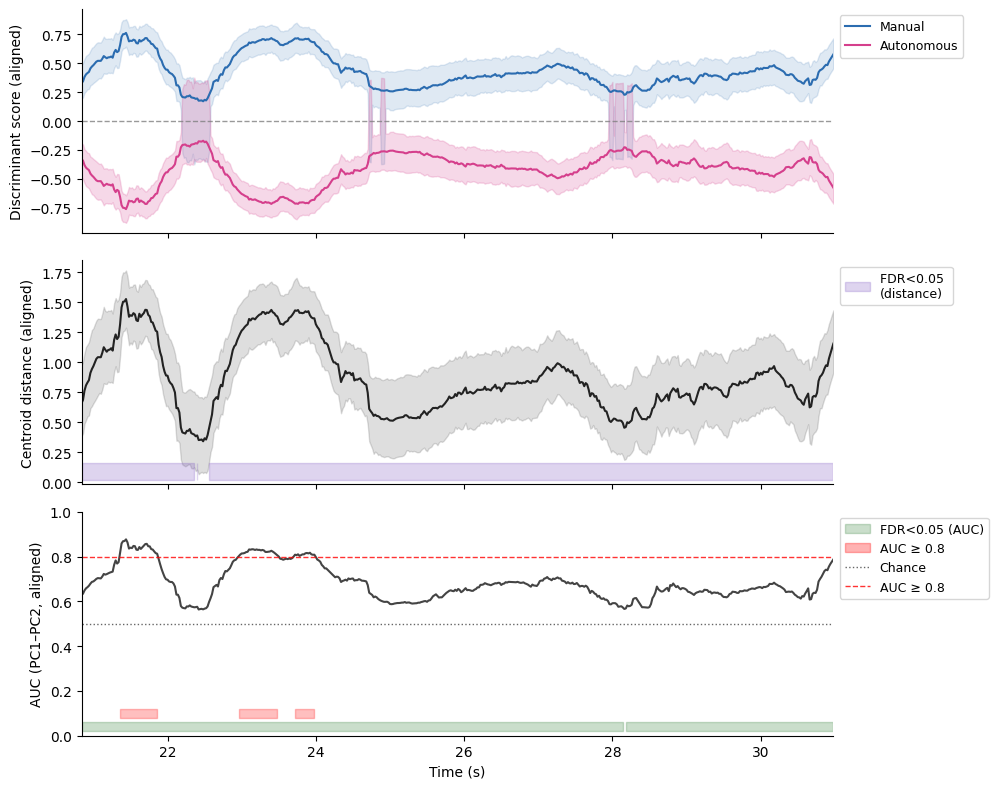

In [74]:
plot_timewise_panels(aligned_df, out_suffix="aligned", ylabel_prefix="aligned")

Saved: /Users/johnmadrid/GitHub/pca-driving-behavior/results/pc-interp/model_performance_aligned.png


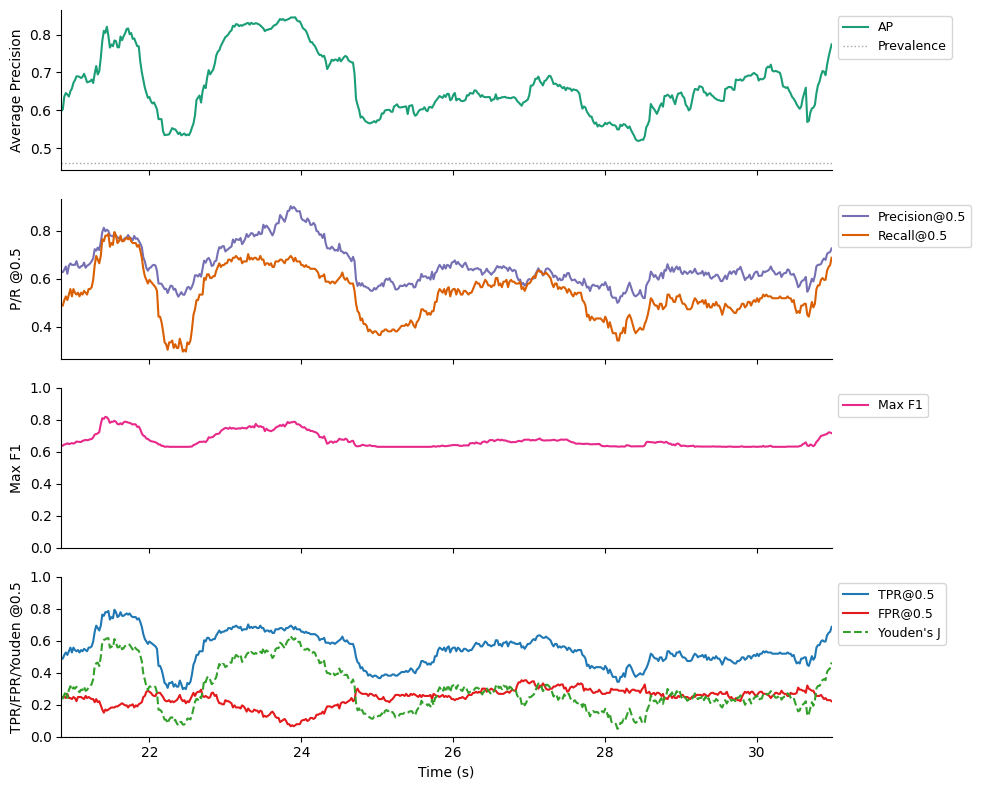

In [82]:
# After computing aligned_df above, call:
plot_model_performance(aligned_df, out_suffix="aligned")

In [83]:
out_df = pd.read_csv(OUTPUT_DIR / "timewise_discriminant_metrics_aligned.csv")
out_df.describe()

,Time,Manual_score_mean,Autonomous_score_mean,Manual_score_lo,Manual_score_hi,Autonomous_score_lo,Autonomous_score_hi,CentroidDistance,CentroidDistance_lo,CentroidDistance_hi,...,f1_max,thresh_f1_max,precision_f1_max,recall_f1_max,prevalence,tpr_0p5,fpr_0p5,youden_j,q_auc,q_dist
count,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,...,508.000000,508.000000,508.000000,508.000000,5.080000e+02,508.000000,508.000000,508.000000,508.000000,508.000000
mean,25.910000,0.431440,-0.431440,0.261603,0.577124,-0.577124,-0.261603,0.862880,0.584654,1.155298,...,0.670834,0.327392,0.566759,0.877878,4.612676e-01,0.539370,0.244082,0.295288,0.008152,0.008229
std,2.935825,0.140861,0.140861,0.216697,0.128283,0.128283,0.216697,0.281722,0.300109,0.254856,...,0.047500,0.112124,0.121081,0.116341,1.111317e-16,0.106103,0.054975,0.141448,0.007338,0.010359
min,20.840000,0.171083,-0.763821,-0.376357,0.320330,-0.882610,-0.644391,0.342165,0.067717,0.697366,...,0.631325,0.066798,0.461268,0.603053,4.612676e-01,0.297710,0.065359,0.049394,0.005797,0.005933
25%,23.375000,0.340312,-0.488752,0.187657,0.492439,-0.629826,-0.359264,0.680623,0.375314,0.984877,...,0.633992,0.233967,0.467092,0.786260,4.612676e-01,0.473282,0.222222,0.202577,0.005797,0.005933
50%,25.910000,0.408012,-0.408012,0.258862,0.550309,-0.550309,-0.258862,0.816024,0.517724,1.100619,...,0.652963,0.336936,0.515225,0.900763,4.612676e-01,0.534351,0.254902,0.264182,0.005797,0.005933
75%,28.445000,0.488752,-0.340312,0.359264,0.629826,-0.492439,-0.187657,0.977503,0.718529,1.259653,...,0.679636,0.411126,0.635970,1.000000,4.612676e-01,0.603053,0.274510,0.361485,0.005797,0.005933
max,30.980000,0.763821,-0.171083,0.644391,0.882610,-0.320330,0.376357,1.527643,1.288782,1.765220,...,0.818841,0.594573,0.907216,1.000000,4.612676e-01,0.793893,0.352941,0.629297,0.054726,0.109453


In [86]:
out_df[out_df["Time"] == 24.0][["AUC","precision_0p5","recall_0p5","Time"]]

,AUC,precision_0p5,recall_0p5,Time
158,0.797685,0.851485,0.656489,24.0


### Step-by-step data flow and AUC computation (diagnostics)
This cell prints, for selected timestamps, the exact data objects used at each stage:
- input behavioral matrix `X` (participants × 7), labels `y`
- standardized data, PCA scores/loadings
- aligned scores/loadings
- discriminant axis and scalar projections
- stratified K-fold splits and held-out probabilities for AUC



In [28]:
from pprint import pprint

# Pick times to debug
if not DEBUG_TIMES and len(unique_times) > 0:
    DEBUG_TIMES = [unique_times[0]]

printed = 0
for t in DEBUG_TIMES:
    if printed >= MAX_DEBUG_PRINTS:
        break
    dft = df[df[TIME_COL] == t].copy()
    X = dft[FEATURES].to_numpy(dtype=float)
    y = dft[COND_COL].to_numpy(dtype=int)

    print("\n=== DEBUG for Time:", t, "===")
    print("Raw input X shape:", X.shape, "(participants × 7)")
    print("First 2 rows of X:")
    print(np.round(X[:2, :], 3))
    print("Labels y shape:", y.shape, "values (first 10):", y[:10])

    # Standardize + PCA
    scores_raw, pca, scaler = _compute_pca_scores(X, n_components=2)
    Xs = scaler.transform(X)
    loadings = pca.components_.T

    print("Standardized Xs mean (approx 0):", np.round(Xs.mean(axis=0), 3))
    print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 4), "| sum=", round(float(np.sum(pca.explained_variance_ratio_)), 4))
    print("Scores_raw shape:", scores_raw.shape, "(participants × 2)")
    print("Check: Xs @ loadings ≈ scores_raw? max|diff|=", float(np.max(np.abs(Xs @ loadings - scores_raw))))
    print("First 2 PC scores (raw):")
    print(np.round(scores_raw[:2, :], 3))
    print("Loadings shape:", loadings.shape, "(7 × 2). Rows follow FEATURES order:")
    for f, row in zip(FEATURES, np.round(loadings, 3)):
        print(f"  {f:>15}: {row}")

    # Alignment (here we use a trivial reference -> R may be identity on the first time)
    aligned_loadings, R = _align_basis(loadings, ref_loadings=None, prev_loadings=None)
    scores = scores_raw @ R
    ortho_err = float(np.linalg.norm(R.T @ R - np.eye(2)))
    detR = float(np.linalg.det(R))
    angle = float(np.degrees(np.arctan2(R[1, 0], R[0, 0])))
    print("Alignment R (2×2):\n", np.round(R, 4), "| orthogonality error=", round(ortho_err, 6), ", det(R)=", round(detR, 6), ", angle(deg)=", round(angle, 2))
    print("Aligned scores (first 2):\n", np.round(scores[:2, :], 3))

    # Show that alignment is a pure rotation in the PC plane (norms preserved)
    pre_norms = np.linalg.norm(scores_raw[:5, :], axis=1)
    post_norms = np.linalg.norm(scores[:5, :], axis=1)
    print("First 5 norms (raw vs aligned):")
    print("  raw:", np.round(pre_norms, 3))
    print("  alg:", np.round(post_norms, 3))

    # Discriminant
    v, m, s, s0, s1, dist = _compute_discriminant(scores, y, prev_v=None)
    print("Discriminant axis v:", np.round(v, 3))
    print("Centroids (Manual, Autonomous) in aligned PC space:")
    c0 = scores[y == 0].mean(axis=0); c1 = scores[y == 1].mean(axis=0)
    print("  c0:", np.round(c0, 3), " c1:", np.round(c1, 3))
    print("Centroid distance:", round(dist, 3))
    print("Group means along v (Manual, Autonomous):", round(s0, 3), round(s1, 3))

    # Stratified K-fold AUC, with explicit splits printed
    class_counts = np.bincount(y)
    max_folds = int(np.clip(class_counts.min(), 2, CV_FOLDS))
    print("Class counts [Manual, Autonomous]:", class_counts.tolist(), "| folds:", max_folds)
    from sklearn.model_selection import StratifiedKFold
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score

    # Save classifier input data for inspection
    classifier_input_df = None

    if max_folds >= 2:
        skf = StratifiedKFold(n_splits=max_folds, shuffle=True, random_state=RANDOM_STATE)
        prob_all = np.zeros(len(y))
        fold_data = []
        for k, (tr, te) in enumerate(skf.split(scores, y), start=1):
            clf = LogisticRegression(C=10.0, solver="lbfgs")
            clf.fit(scores[tr], y[tr])
            prob = clf.predict_proba(scores[te])[:, 1]
            prob_all[te] = prob
            print(f"  Fold {k}: train={len(tr)} (shape {scores[tr].shape}), test={len(te)} (shape {scores[te].shape}) | prob[0:2]", np.round(prob[:2], 3))
            # Save the data for this fold
            fold_df = {
                'fold': k,
                'train_scores': scores[tr],
                'train_labels': y[tr],
                'test_scores': scores[te],
                'test_labels': y[te],
                'test_prob': prob
            }
            fold_data.append(fold_df)
        # Save all fold data into a DataFrame for inspection
        import pandas as pd
        classifier_input_df = pd.DataFrame({
            'fold': [fd['fold'] for fd in fold_data],
            'train_scores': [fd['train_scores'] for fd in fold_data],
            'train_labels': [fd['train_labels'] for fd in fold_data],
            'test_scores': [fd['test_scores'] for fd in fold_data],
            'test_labels': [fd['test_labels'] for fd in fold_data],
            'test_prob': [fd['test_prob'] for fd in fold_data]
        })
        print("Saved classifier input data for all folds to 'classifier_input_df' (shape:", classifier_input_df.shape, ")")
        auc = roc_auc_score(y, prob_all)
        print("AUC (out-of-fold):", round(auc, 3))
    else:
        clf = LogisticRegression(C=10.0, solver="lbfgs")
        clf.fit(scores, y)
        prob = clf.predict_proba(scores)[:, 1]
        auc = roc_auc_score(y, prob)
        # Save the single in-sample classifier input
        import pandas as pd
        classifier_input_df = pd.DataFrame({
            'scores': [scores],
            'labels': [y],
            'prob': [prob]
        })
        print("Saved classifier input data for in-sample fit to 'classifier_input_df' (shape:", classifier_input_df.shape, ")")
        print("AUC (in-sample; low-N fallback):", round(auc, 3))

    printed += 1



=== DEBUG for Time: 20.84 ===
Raw input X shape: (284, 7) (participants × 7)
First 2 rows of X:
[[ -1.625  -6.56   65.079  -3.083  -2.037   8.03   -1.787]
 [-10.819  15.434  64.753  -3.855   4.26   -7.098  -1.787]]
Labels y shape: (284,) values (first 10): [0 0 0 0 0 0 0 0 0 0]
Standardized Xs mean (approx 0): [ 0. -0. -0. -0.  0.  0.  0.]
Explained variance ratio (PC1, PC2): [0.2671 0.1922] | sum= 0.4593
Scores_raw shape: (284, 2) (participants × 2)
Check: Xs @ loadings ≈ scores_raw? max|diff|= 4.884981308350689e-15
First 2 PC scores (raw):
[[ 1.23  -0.62 ]
 [-2.773 -0.751]]
Loadings shape: (7, 2) (7 × 2). Rows follow FEATURES order:
   Eye Horizontal: [0.139 0.55 ]
     Eye Vertical: [-0.583  0.051]
          Car Yaw: [0.025 0.11 ]
         Head Yaw: [-0.148 -0.577]
       Head Pitch: [-0.489  0.282]
        Head Roll: [0.615 0.024]
         Steering: [ 0.024 -0.52 ]
Alignment R (2×2):
 [[1. 0.]
 [0. 1.]] | orthogonality error= 0.0 , det(R)= 1.0 , angle(deg)= 0.0
Aligned scores (fir

In [27]:
classifier_input_df['test_labels'][0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [22]:
len(y)

284